In [1]:
import warnings
import duckdb
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view
import pandas as pd
from matplotlib import pyplot as plt

cols = duckdb.read_parquet('../data/processed/BTCUSDT_2021_2026.parquet').fetchnumpy()

tf = 60

cols['open_time'] = cols['open_time'][tf-1:]
cols['open'] = cols['open'][:1-tf]
cols['high'] = sliding_window_view(cols['high'], tf).max(1)
cols['low'] = sliding_window_view(cols['low'], tf).min(1)
cols['close'] = cols['close'][tf-1:]
cols['volume'] = sliding_window_view(cols['volume'], tf).sum(1)
cols['qav'] = sliding_window_view(cols['qav'], tf).sum(1)
cols['n_trades'] = sliding_window_view(cols['n_trades'], tf).sum(1)
cols['buy_volume'] = sliding_window_view(cols['buy_volume'], tf).sum(1)
cols['buy_qav'] = sliding_window_view(cols['buy_qav'], tf).sum(1)

print(cols.keys())

dict_keys(['open_time', 'open', 'high', 'low', 'close', 'volume', 'qav', 'n_trades', 'buy_volume', 'buy_qav'])


In [2]:
with warnings.catch_warnings():
  warnings.simplefilter('ignore')

  tmp00 = cols['volume'] - cols['buy_volume']
  tmp01 = cols['qav'] - cols['buy_qav']
  tmp02 = cols['buy_volume'] / cols['buy_qav']
  tmp03 = tmp00 / tmp01

  tmp04 = cols['buy_qav'] / tmp01
  tmp05 = cols['buy_volume'] / tmp00

  tmp06 = cols['open'] * tmp02
  tmp07 = cols['open'] * tmp03

  tmp08 = cols['high'] * tmp02
  tmp09 = cols['low'] * tmp03

  tmp10 = cols['close'] * tmp02
  tmp11 = cols['close'] * tmp03

  tmp12 = np.where(
    cols['close'] > cols['open'],
    (cols['close'] * cols['low']) / np.square(cols['open']),
    (cols['open'] * cols['low']) / np.square(cols['close'])
  )

  tmp13 = cols['buy_volume'] / np.roll(cols['buy_volume'], tf)
  tmp14 = cols['buy_qav'] / np.roll(cols['buy_qav'], tf)
  tmp15 = cols['n_trades'] / np.roll(cols['n_trades'], tf)

  src = np.log(np.stack((
    tmp04,
    tmp05 / tmp04,
    tmp06 * tmp07,
    tmp08 * tmp09,
    tmp10 * tmp11,
    tmp12,
    tmp13,
    tmp13 / tmp14,
    tmp13 / tmp15
  ), 1))

valid_mask = np.isfinite(src).all(1) & (np.arange(len(src)) >= tf)
src_valid = src[valid_mask]

feat_corr = np.corrcoef(src_valid, rowvar=False)
pos_frac = (src_valid > 0.0).mean(0)

display(pd.DataFrame(feat_corr))
display(pd.Series(pos_frac))

,0,1,2,3,4,5,6,7,8
0,1.000000,-0.001535,-0.474021,-0.154472,0.369951,0.082880,0.156334,-0.367673,0.442787
1,-0.001535,1.000000,-0.037308,-0.013474,-0.001182,0.130816,-0.021873,-0.021053,-0.020784
2,-0.474021,-0.037308,1.000000,0.368458,-0.425157,-0.233407,-0.027580,0.838900,-0.175066
3,-0.154472,-0.013474,0.368458,1.000000,-0.107933,0.030332,-0.016194,0.277545,-0.074001
4,0.369951,-0.001182,-0.425157,-0.107933,1.000000,-0.145026,0.052923,-0.307683,0.176270
5,0.082880,0.130816,-0.233407,0.030332,-0.145026,1.000000,0.229607,-0.209380,0.141601
6,0.156334,-0.021873,-0.027580,-0.016194,0.052923,0.229607,1.000000,0.031276,0.749217
7,-0.367673,-0.021053,0.838900,0.277545,-0.307683,-0.209380,0.031276,1.000000,-0.041963
8,0.442787,-0.020784,-0.175066,-0.074001,0.176270,0.141601,0.749217,-0.041963,1.000000


0    0.477902
1    0.191233
2    0.500638
3    0.487310
4    0.508583
5    0.616213
6    0.467493
7    0.492009
8    0.497658
dtype: float64

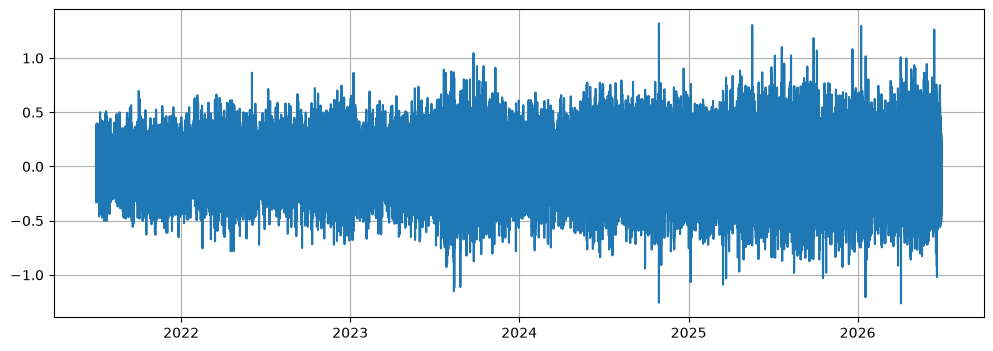

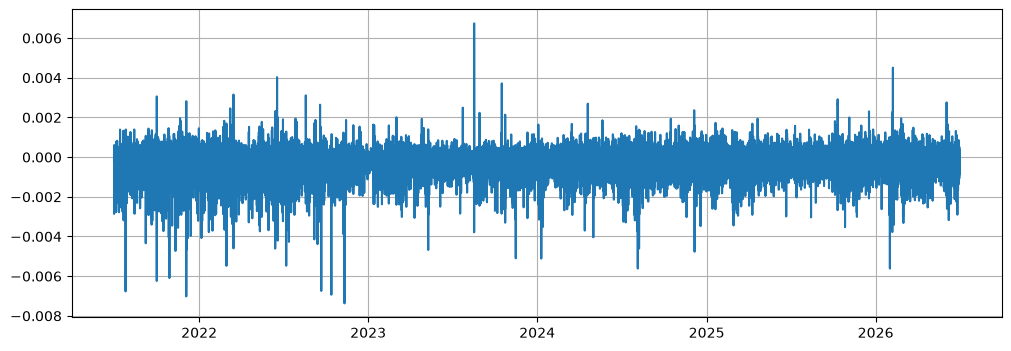

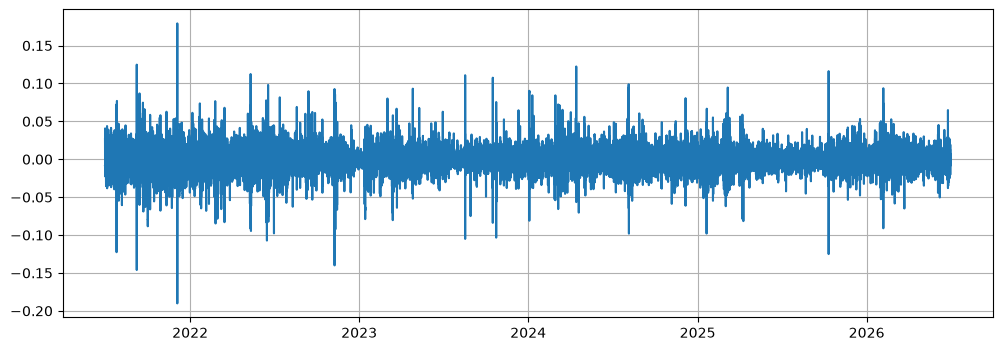

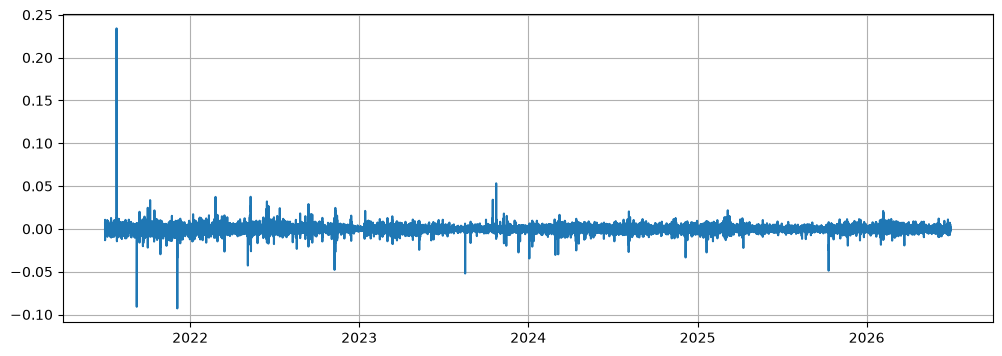

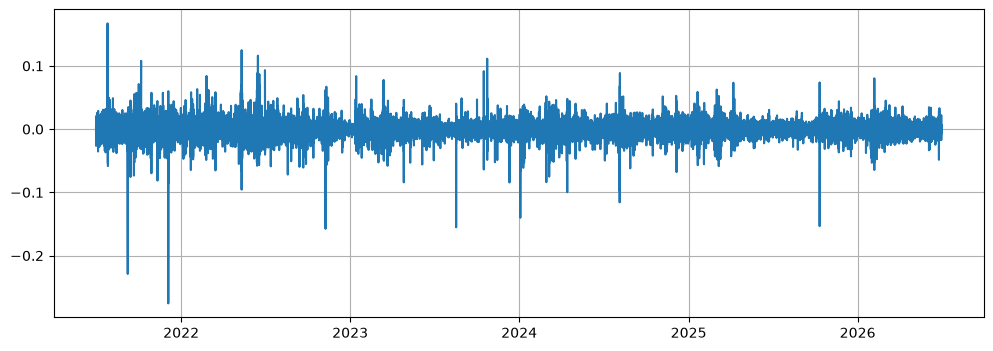

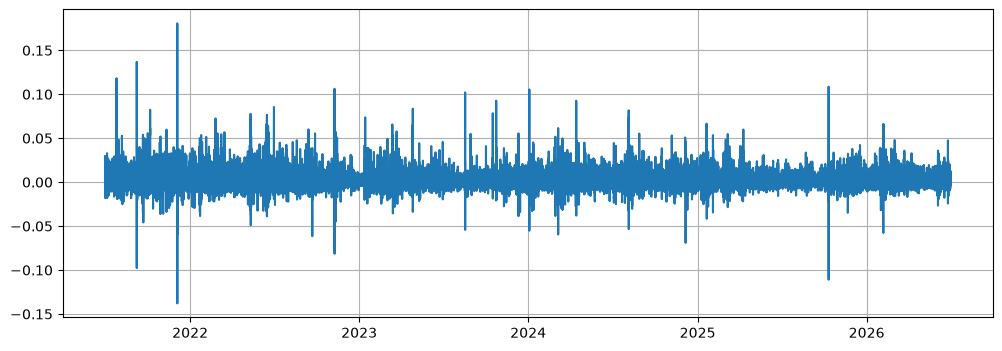

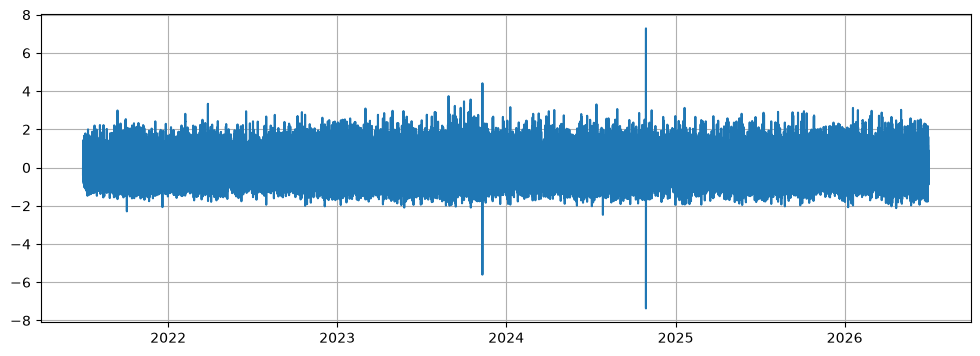

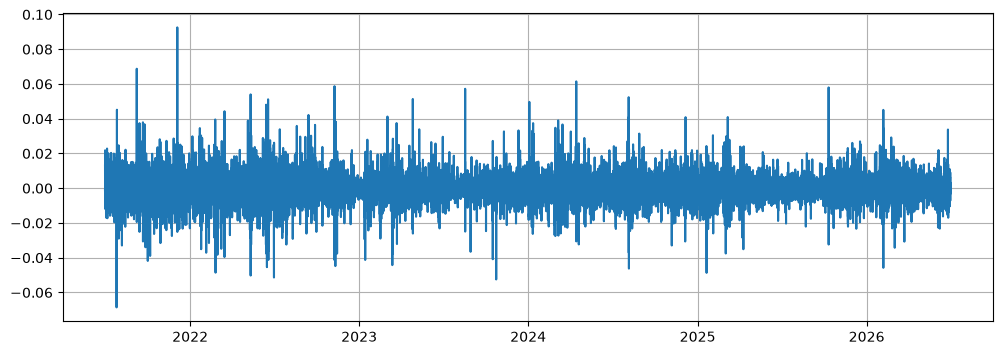

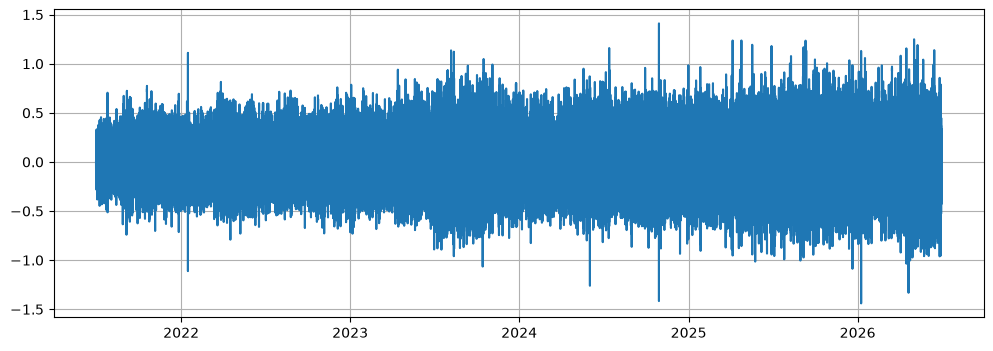

In [3]:
idxs = cols['open_time'][valid_mask]
for feats in src_valid.T:
  plt.figure(figsize=(12, 4))
  plt.plot(idxs, feats)
  plt.grid()
  plt.show()